# MLB Offensive Production Analysis

This notebook evaluates same-season associations between offensive production and hitter traits for model-eligible player-seasons in the cached 2024–2026 dataset. It is not a causal analysis or a next-season forecast.

Primary outcome: FanGraphs **wRC+**. OPS, OPS+, wOBA, and xwOBA are reported as outcomes/context but are intentionally excluded from wRC+ predictors to avoid formulaic leakage. Evaluation uses grouped cross-validation by `player_id`, so a player's repeated seasons are never split between training and test data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from mlb_offense.analysis import (
    AnalysisConfig,
    bootstrap_model_difference,
    clustered_ols_coefficients,
    coverage_by_season,
    evaluate_models,
    feature_sets,
    grouped_permutation_importance,
    load_analysis_data,
    missingness_by_season,
    plot_correlation,
    plot_missingness,
    plot_outcome_distributions,
    plot_predictions,
    plot_residual_diagnostics,
)

DATA_PATH = Path('data/processed/mlb_offense_2024_2026.parquet')
OUTPUT_DIR = Path('data/analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = AnalysisConfig(
    min_pa=100,
    min_competitive_swings=50,
    outer_splits=5,
    inner_splits=3,
    bootstrap_iterations=500,
)
data = load_analysis_data(DATA_PATH, config)
blocks = feature_sets(data)
print(f'{len(data):,} eligible player-seasons across {data.player_id.nunique():,} hitters')

1,315 eligible player-seasons across 616 hitters


## Sample coverage and descriptive outcomes

The local thresholds are intentionally applied after data collection. This keeps the raw source responses intact and makes sensitivity checks straightforward.

In [2]:
display(coverage_by_season(data).style.format(precision=3))
display(
    data.groupby('season')[['pa', 'competitive_swings', 'wrc_plus', 'ops_plus', 'woba', 'xwoba']]
    .describe()
)

,season,player_seasons,unique_players,median_pa,median_competitive_swings,wrc_plus_coverage,ops_plus_coverage,woba_coverage,xwoba_coverage,avg_bat_speed_coverage,attack_angle_coverage,distance_off_plate_coverage
0,2024,455,455,369.000,576.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
1,2025,461,461,376.000,594.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
2,2026,399,399,263.000,420.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


pa                                                             \
        count        mean         std    min    25%    50%    75%    max   
season                                                                     
2024    455.0  383.263736  177.660484  103.0  233.0  369.0  528.0  735.0   
2025    461.0  378.694143  187.601033  100.0  206.0  376.0  544.0  732.0   
2026    399.0  271.498747  110.298610  100.0  172.5  263.0  377.0  484.0   

       competitive_swings              ...   woba         xwoba            \
                    count        mean  ...    75%    max  count      mean   
season                                 ...                                  
2024                455.0  597.740659  ...  0.327  0.476  455.0  0.309035   
2025                461.0  611.989154  ...  0.333  0.463  461.0  0.307989   
2026                399.0  435.065163  ...  0.341  0.454  399.0  0.314150   

                                                       
             std    min     25%    50%     75%    max  
season                                                 
2024    0.036621  0.171  0.2850  0.306  0.3300  0.480  
2025    0.037920  0.202  0.2840  0.308  0.3300  0.460  
2026    0.036880  0.212  0.2885  0.311  0.3395  0.477  

[3 rows x 48 columns]

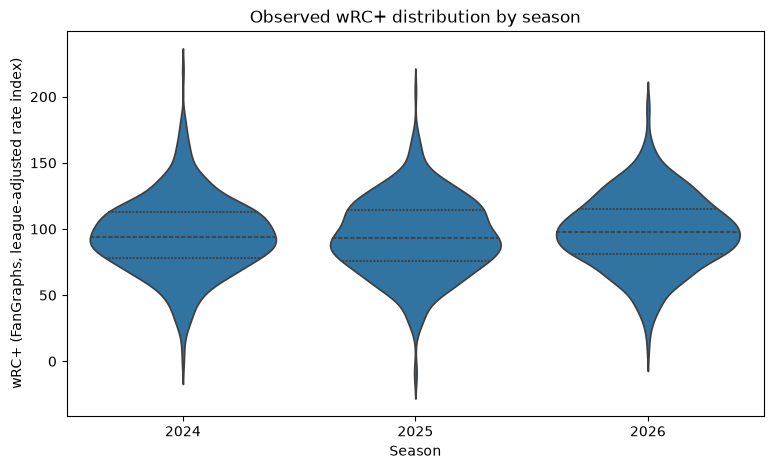

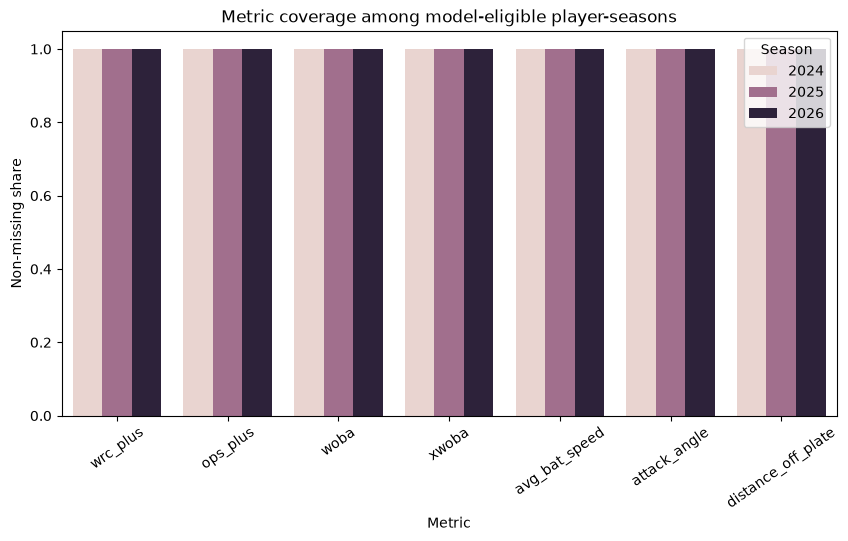

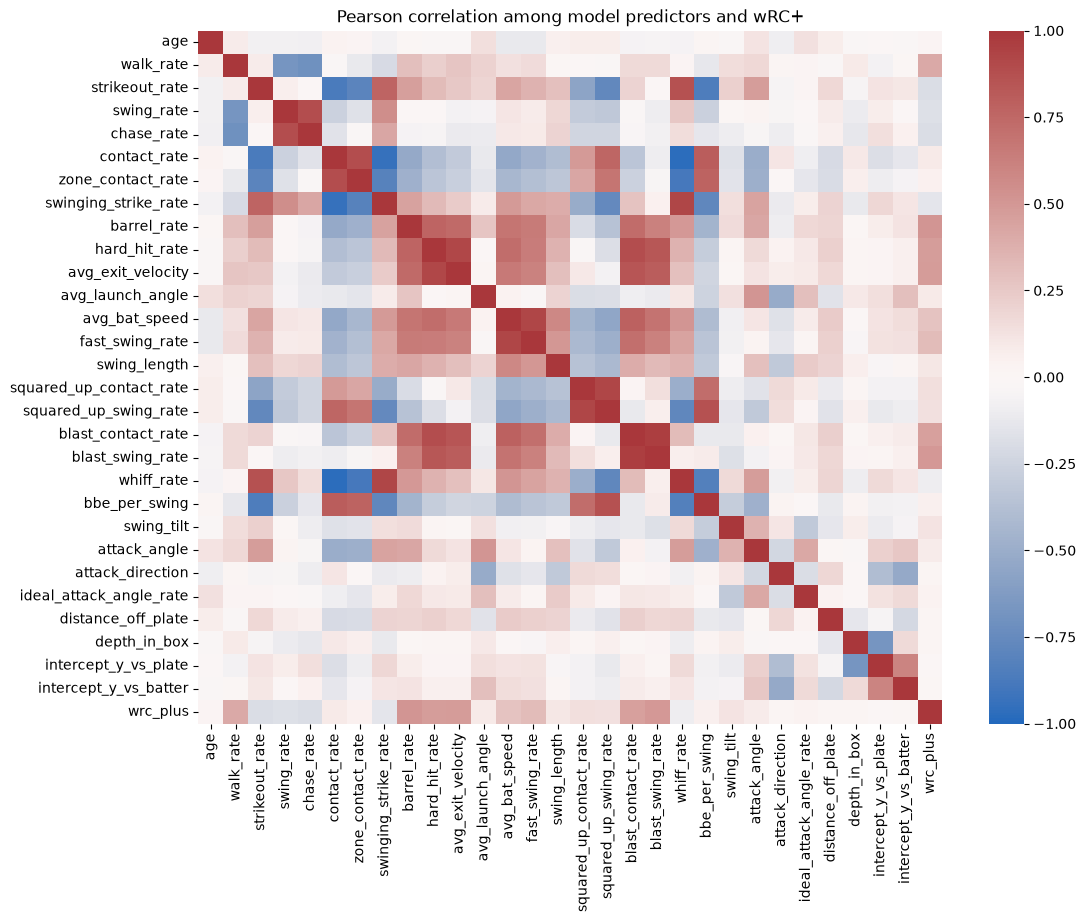

,season,metric,missing_rate


In [3]:
figures = [
    plot_outcome_distributions(data),
    plot_missingness(data),
    plot_correlation(data, blocks['core_plus_traits']),
]
for number, figure in enumerate(figures, start=1):
    figure.savefig(OUTPUT_DIR / f'eda_{number}.png', dpi=160, bbox_inches='tight')
    plt.show()

display(missingness_by_season(data).sort_values(['season', 'missing_rate'], ascending=[True, False]).head(20))

## Leakage-safe grouped model evaluation

Predictors are evaluated in two prespecified blocks: `core` contains age, handedness, season, plate discipline, and contact-quality measures; `core_plus_traits` adds bat-tracking and stance fields. Production metrics and their components are excluded. Hyperparameters are tuned inside each training fold; the outer evaluation folds are grouped by hitter.

In [4]:
performance, predictions, selected_parameters = evaluate_models(data, config)
performance.to_csv(OUTPUT_DIR / 'grouped_cv_performance.csv', index=False)
predictions.to_parquet(OUTPUT_DIR / 'out_of_fold_predictions.parquet', index=False)
selected_parameters.to_json(OUTPUT_DIR / 'selected_parameters.json', orient='records', indent=2)

display(
    performance.style.format({
        'mae': '{:.2f}', 'rmse': '{:.2f}', 'r2': '{:.3f}',
        'calibration_intercept': '{:.2f}', 'calibration_slope': '{:.3f}',
        'pa_weighted_mae': '{:.2f}', 'pa_weighted_rmse': '{:.2f}',
        'pa_weighted_r2': '{:.3f}',
    })
)

,model,feature_block,model_family,mae,rmse,r2,calibration_intercept,calibration_slope,pa_weighted_mae,pa_weighted_rmse,pa_weighted_r2,pa_weighted_calibration_intercept,pa_weighted_calibration_slope,n_observations,n_players
0,elastic_net:core_plus_traits,core_plus_traits,elastic_net,14.23,18.50,0.571,-0.57,1.006,12.56,16.24,0.627,-0.571911,1.005952,1315,616
1,ridge:core_plus_traits,core_plus_traits,ridge,14.27,18.53,0.570,1.26,0.987,12.61,16.28,0.625,1.262024,0.986805,1315,616
2,ols:core_plus_traits,core_plus_traits,ols,14.30,18.58,0.568,3.12,0.968,12.63,16.31,0.624,3.120556,0.967706,1315,616
3,elastic_net:core,core,elastic_net,14.52,18.88,0.553,-2.03,1.021,12.92,16.64,0.609,-2.027528,1.021034,1315,616
4,ridge:core,core,ridge,14.52,18.87,0.554,0.19,0.998,12.92,16.62,0.610,0.188718,0.997975,1315,616
5,ols:core,core,ols,14.57,18.90,0.552,1.47,0.985,12.96,16.64,0.609,1.466344,0.984615,1315,616
6,random_forest:core,core,random_forest,15.47,20.11,0.493,-11.21,1.118,14.04,18.13,0.535,-11.214604,1.118178,1315,616
7,random_forest:core_plus_traits,core_plus_traits,random_forest,15.68,20.30,0.484,-13.62,1.144,14.27,18.38,0.522,-13.623540,1.144026,1315,616
8,mean_baseline:baseline,baseline,mean_baseline,22.16,28.27,-0.002,477.58,-4.000,21.27,27.45,-0.065,477.581364,-4.000000,1315,616


,metric,candidate_model,reference_model,difference,ci_lower,ci_upper,iterations
0,mae,elastic_net:core_plus_traits,elastic_net:core,-0.284,-0.477,-0.078,500


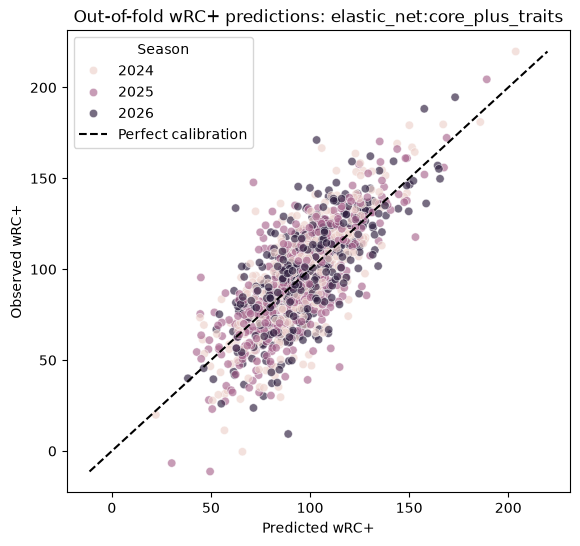

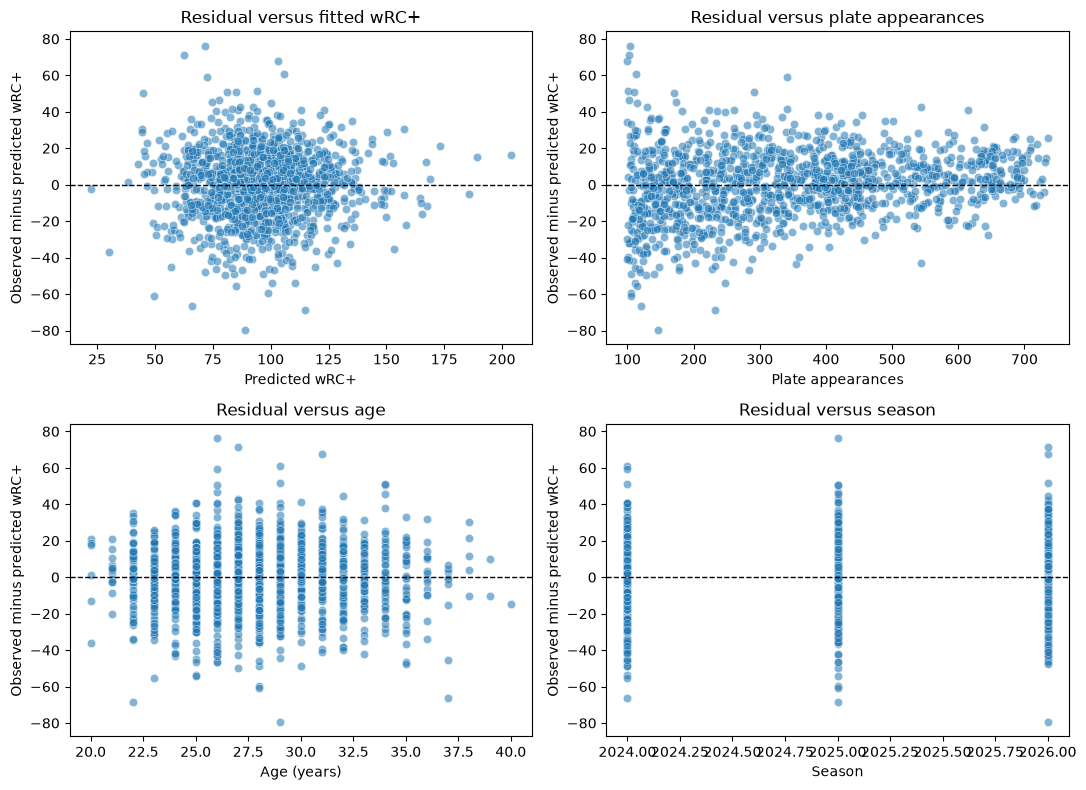

In [5]:
comparison = bootstrap_model_difference(
    predictions,
    candidate_model='elastic_net:core_plus_traits',
    reference_model='elastic_net:core',
    metric='mae',
    iterations=config.bootstrap_iterations,
    random_state=config.random_state,
)
comparison.to_csv(OUTPUT_DIR / 'elastic_net_trait_increment_bootstrap.csv', index=False)
display(comparison.style.format({'difference': '{:.3f}', 'ci_lower': '{:.3f}', 'ci_upper': '{:.3f}'}))

best_model = performance.iloc[0]['model']
prediction_figure = plot_predictions(predictions, best_model)
prediction_figure.savefig(OUTPUT_DIR / 'best_model_calibration.png', dpi=160, bbox_inches='tight')
plt.show()

residual_figure = plot_residual_diagnostics(predictions, best_model, data)
residual_figure.savefig(OUTPUT_DIR / 'best_model_residuals.png', dpi=160, bbox_inches='tight')
plt.show()

## Interpretation aids

The standardized OLS coefficients below use player-clustered standard errors. Permutation importance is descriptive: correlated hitter traits can substitute for each other and are not independent causal effects.

In [6]:
coefficients = clustered_ols_coefficients(data, blocks['core_plus_traits'], config)
coefficients.to_csv(OUTPUT_DIR / 'clustered_ols_coefficients.csv', index=False)
display(coefficients.head(20).style.format({
    'coefficient': '{:.3f}', 'std_error': '{:.3f}', 'ci_lower': '{:.3f}',
    'ci_upper': '{:.3f}', 'p_value': '{:.4f}',
}))

importance = grouped_permutation_importance(data, blocks['core_plus_traits'], config)
importance.to_csv(OUTPUT_DIR / 'permutation_importance.csv', index=False)
display(importance.head(20).style.format({'importance_mean': '{:.3f}', 'importance_std': '{:.3f}'}))

,feature,coefficient,std_error,ci_lower,ci_upper,p_value
0,const,97.051,1.667,93.784,100.318,0.0000
1,strikeout_rate,-20.701,2.068,-24.755,-16.647,0.0000
2,barrel_rate,14.402,1.186,12.078,16.726,0.0000
3,squared_up_swing_rate,-9.132,8.714,-26.210,7.947,0.2946
4,blast_contact_rate,8.329,7.452,-6.276,22.934,0.2637
5,bbe_per_swing,-7.992,2.982,-13.837,-2.147,0.0074
6,avg_bat_speed,-6.604,2.542,-11.586,-1.622,0.0094
7,season_2025,-5.876,1.174,-8.176,-3.575,0.0000
8,squared_up_contact_rate,5.778,6.610,-7.177,18.733,0.3820
9,whiff_rate,-5.180,5.419,-15.801,5.441,0.3391


,feature,importance_mean,importance_std
0,barrel_rate,4.673,0.183
1,strikeout_rate,2.886,0.120
2,blast_swing_rate,2.727,0.163
3,walk_rate,2.467,0.139
4,hard_hit_rate,1.106,0.061
5,avg_exit_velocity,0.490,0.025
6,swing_tilt,0.291,0.018
7,contact_rate,0.279,0.024
8,whiff_rate,0.235,0.015
9,swinging_strike_rate,0.223,0.021


## Interpretation checklist

- The table compares observed production in the same season, so it should be interpreted as association rather than prediction or causation.
- Compare `elastic_net:core_plus_traits` against `elastic_net:core` and inspect the bootstrapped MAE difference to assess incremental value from bat and stance traits.
- Check residual plots and calibration before trusting aggregate error statistics.
- Re-run with alternative PA and competitive-swing thresholds before making conclusions about the MLB hitter population.